In [22]:
import pandas as pd
import json
from pprint import pprint
from collections import defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt

In [9]:
with open("data/questions/NuScenes_train_questions.json") as f:
    questions = json.load(f)["questions"]

{
            "split": "val",
            "sample_token": "fd8420396768425eabec9bdddf7e64b6",
            "question": "Are any moving bicycles visible?",
            "answer": "no",
            "num_hop": 0,
            "template_type": "exist"
        },

In [19]:
counter_dict = defaultdict(int)

for q in tqdm(questions):
    counter_dict[q["answer"]] += 1

100%|██████████| 376604/376604 [00:00<00:00, 6455744.91it/s]


In [20]:
counter_dict

defaultdict(int,
            {'moving': 15492,
             'parked': 13973,
             '2': 7611,
             '3': 7611,
             'yes': 95195,
             'no': 77589,
             'car': 19800,
             'truck': 12717,
             'pedestrian': 17764,
             'not standing': 1173,
             '1': 6547,
             '0': 5652,
             '9': 5836,
             '4': 7587,
             'traffic cone': 2900,
             '5': 7388,
             '6': 7229,
             '7': 6834,
             '10': 5380,
             'standing': 3771,
             'construction vehicle': 3537,
             'barrier': 2393,
             'motorcycle': 5062,
             'with rider': 3269,
             '8': 6473,
             'without rider': 5697,
             'bicycle': 5046,
             'stopped': 9258,
             'bus': 4374,
             'trailer': 3446})

In [21]:
len(counter_dict)

30

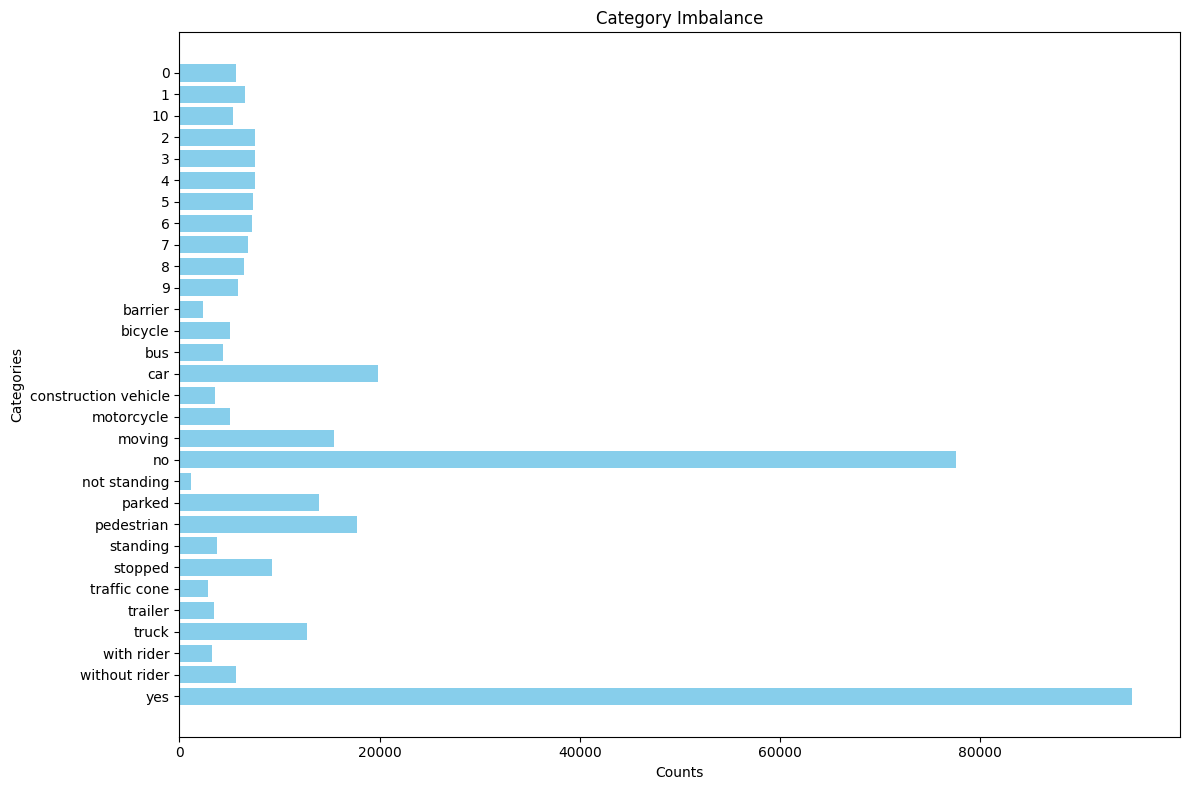

In [63]:
categories = list(counter_dict.keys())
values = list(counter_dict.values())

categories, values = zip(*sorted(zip(categories, values)))

# Plotting
plt.figure(figsize=(12, 8))
plt.barh(categories, values, color='skyblue')
plt.xlabel('Counts')
plt.ylabel('Categories')
plt.title('Category Imbalance')
plt.gca().invert_yaxis()  # Optional: invert y-axis for better readability
plt.tight_layout()
plt.show()

In [50]:
with open("outputs/result/result_run_5195355_epoch0.txt") as f:
    results = f.readlines()

In [52]:
result_counter = {x.replace(" ", "_"):{"correct":0, "wrong":0} for x in categories}

for res in results:
    answers = res.split("?")[-1]
    answers = (answers
        .replace("not standing", "not_standing")
        .replace("traffic cone", "traffic_cone")
        .replace("construction vehicle", "construction_vehicle")
        .replace("with rider", "with_rider")
        .replace("without rider", "without_rider")
    )
    
    actual = answers.split()[0].strip()
    predicted = answers.split()[1].strip()

    is_correct = actual == predicted
    # print(result_counter[actual])
    if is_correct:
        result_counter[actual]["correct"] += 1
    else:
        result_counter[actual]["wrong"] += 1

    # print(result_counter[actual])
    # break

In [53]:
result_counter


{'moving': {'correct': 1723, 'wrong': 1959},
 'parked': {'correct': 1778, 'wrong': 1721},
 '2': {'correct': 268, 'wrong': 1408},
 '3': {'correct': 245, 'wrong': 1413},
 'yes': {'correct': 16310, 'wrong': 4647},
 'no': {'correct': 12276, 'wrong': 4208},
 'car': {'correct': 1990, 'wrong': 3197},
 'truck': {'correct': 804, 'wrong': 2109},
 'pedestrian': {'correct': 2559, 'wrong': 1769},
 'not_standing': {'correct': 19, 'wrong': 108},
 '1': {'correct': 409, 'wrong': 1284},
 '0': {'correct': 763, 'wrong': 472},
 '9': {'correct': 168, 'wrong': 1228},
 '4': {'correct': 199, 'wrong': 1361},
 'traffic_cone': {'correct': 105, 'wrong': 318},
 '5': {'correct': 154, 'wrong': 1285},
 '6': {'correct': 150, 'wrong': 1204},
 '7': {'correct': 209, 'wrong': 1381},
 '10': {'correct': 241, 'wrong': 1232},
 'standing': {'correct': 229, 'wrong': 430},
 'construction_vehicle': {'correct': 129, 'wrong': 433},
 'barrier': {'correct': 109, 'wrong': 290},
 'motorcycle': {'correct': 648, 'wrong': 504},
 'with_ride

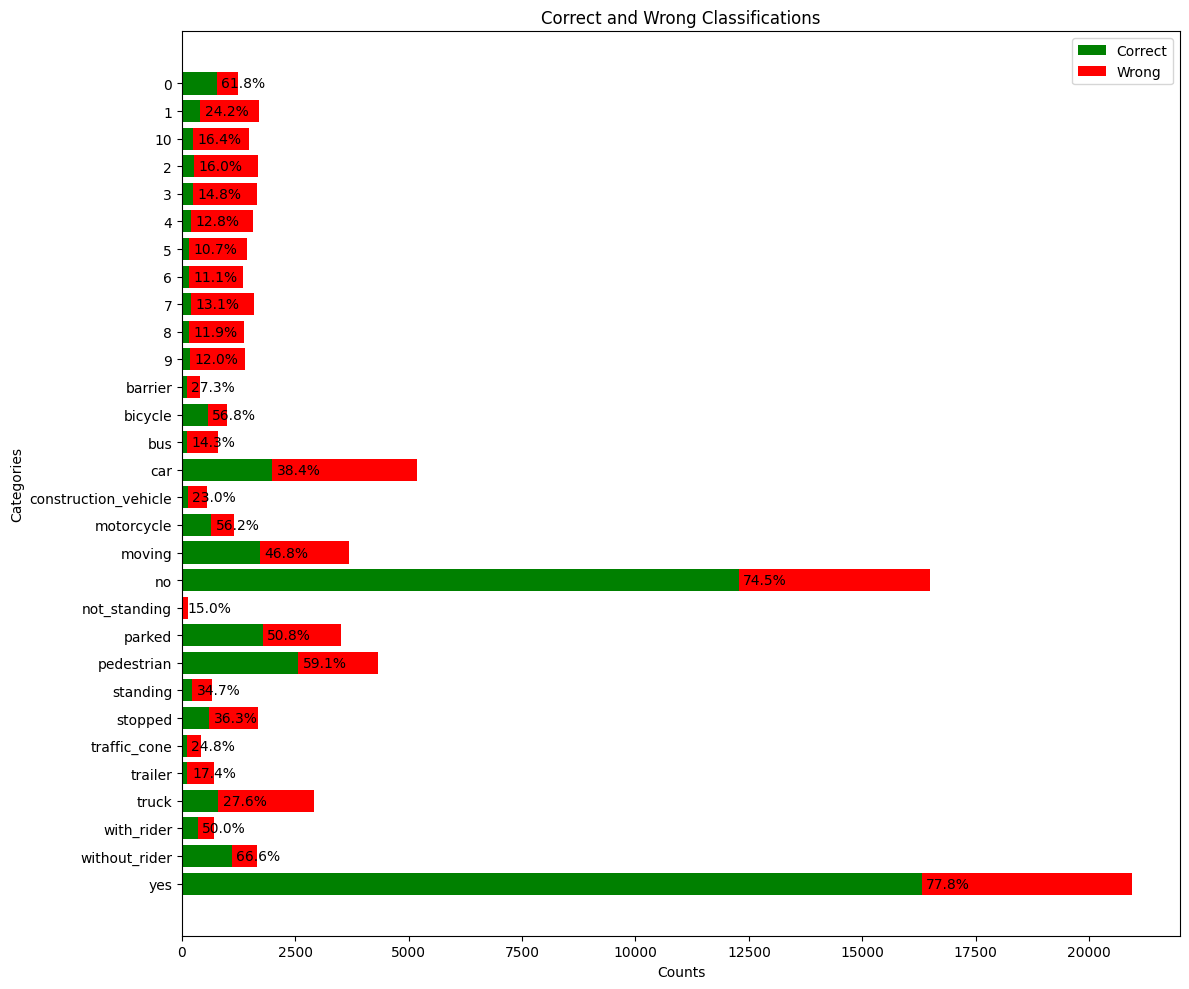

In [58]:
categories = sorted(list(result_counter.keys()), reverse=True)
correct_counts = [result_counter[category]['correct'] for category in categories]
wrong_counts = [result_counter[category]['wrong'] for category in categories]

# Calculate the correct percentage for each category
percentages = [
    f"{(correct / (correct + wrong)) * 100:.1f}%" 
    for correct, wrong in zip(correct_counts, wrong_counts)
]

# Plotting
fig, ax = plt.subplots(figsize=(12, 10))

# Plot correct counts in green
bars_correct = ax.barh(categories, correct_counts, color='green', label='Correct')

# Plot wrong counts in red, shifted by correct counts
bars_wrong = ax.barh(categories, wrong_counts, color='red', left=correct_counts, label='Wrong')

# Adding labels and title
plt.xlabel('Counts')
plt.ylabel('Categories')
plt.title('Correct and Wrong Classifications')
plt.legend(loc='upper right')

# Annotate with percentage correct
for bar, percentage in zip(bars_correct, percentages):
    plt.text(
        bar.get_width() + 100,  # Adjusts position to right of bar
        bar.get_y() + bar.get_height() / 2,
        percentage,
        va='center'
    )

plt.tight_layout()
plt.show()